# imports

In [1]:
!pip install retina-face tqdm -q

import os, cv2, numpy as np, shutil, random, time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from retinaface import RetinaFace
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Global variables
BASE = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"
OUTPUT_DIR = "/kaggle/working/frames"
TRAIN_DIR = "/kaggle/working/train"
VAL_DIR = "/kaggle/working/val"
TEST_DIR = "/kaggle/working/test"
IMG_SIZE = 224
PADDING = 20
FAKE_DIRS = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures", "FaceShifter", "DeepFakeDetection"]

print("Ready")

2026-05-16 21:12:45.146803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778965965.331063      94 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778965965.391340      94 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778965965.822461      94 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778965965.822505      94 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778965965.822508      94 computation_placer.cc:177] computation placer alr

Ready


# extract faces (retinaface in parallel)

In [2]:
assert os.path.exists(BASE), "Dataset not found — check Kaggle input path"

os.makedirs(f"{OUTPUT_DIR}/real", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/fake", exist_ok=True)

def extract_faces(folder, label, max_videos=80, frames_per_video=15):
    folder_name = os.path.basename(folder)
    if label == 0:
        out_folder = f"{OUTPUT_DIR}/real"
    else:
        out_folder = f"{OUTPUT_DIR}/fake_temp/{folder_name}"
        os.makedirs(out_folder, exist_ok=True)

    videos = [f for f in os.listdir(folder) if f.endswith(".mp4")][:max_videos]
    if not videos:
        print(f"No videos found in {folder_name}")
        return

    saved = 0
    skipped = 0
    blur_threshold = 20 if label == 1 else 50

    for v in tqdm(videos, desc=f"{'Real' if label==0 else 'Fake'} - {folder_name}"):
        path = os.path.join(folder, v)
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            skipped += 1
            continue

        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            cap.release()
            skipped += 1
            continue

        # Don't request more frames than video has
        actual_frames = min(frames_per_video, total)
        step = max(total // actual_frames, 1)

        for i in range(actual_frames):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
            ret, frame = cap.read()
            if not ret or frame is None:
                continue

            # Skip blurry frames
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            if cv2.Laplacian(gray, cv2.CV_64F).var() < blur_threshold:
                skipped += 1
                continue

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            try:
                faces = RetinaFace.detect_faces(rgb)
            except Exception:
                continue

            if not isinstance(faces, dict) or len(faces) == 0:
                continue

            # Pick largest face not just first
            best_face = max(faces.keys(), key=lambda k: (
                faces[k]['facial_area'][2] - faces[k]['facial_area'][0]) *
                (faces[k]['facial_area'][3] - faces[k]['facial_area'][1])
            )
            x1, y1, x2, y2 = faces[best_face]['facial_area']
            x1 = max(0, x1 - PADDING)
            y1 = max(0, y1 - PADDING)
            x2 = min(rgb.shape[1], x2 + PADDING)
            y2 = min(rgb.shape[0], y2 + PADDING)
            face = rgb[y1:y2, x1:x2]

            if face is None or face.size == 0 or face.shape[0] < 10 or face.shape[1] < 10:
                continue

            face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
            fname = f"{folder_name}_{os.path.splitext(v)[0]}_f{i}.png"
            out_path = os.path.join(out_folder, fname)

            # Verify write succeeded
            if not cv2.imwrite(out_path, cv2.cvtColor(face, cv2.COLOR_RGB2BGR),
                               [cv2.IMWRITE_PNG_COMPRESSION, 1]):
                continue

            saved += 1

        cap.release()
    print(f" {folder_name}: {saved} saved | {skipped} skipped")

# Real — sequential
start_time = time.time()
extract_faces(os.path.join(BASE, "original"), 0, max_videos=80, frames_per_video=15)

# Fake — sequential to avoid GPU memory conflicts
for fd in FAKE_DIRS:
    extract_faces(os.path.join(BASE, fd), 1, max_videos=80, frames_per_video=15)

# Merge fake temp folders
print("\nMerging fake folders...")
for fd in FAKE_DIRS:
    temp_folder = f"{OUTPUT_DIR}/fake_temp/{fd}"
    if not os.path.exists(temp_folder):
        continue
    for f in os.listdir(temp_folder):
        shutil.move(os.path.join(temp_folder, f), f"{OUTPUT_DIR}/fake/{f}")
shutil.rmtree(f"{OUTPUT_DIR}/fake_temp")

real_count = len(os.listdir(f"{OUTPUT_DIR}/real"))
fake_count = len(os.listdir(f"{OUTPUT_DIR}/fake"))
print(f"\nExtraction Done. Real: {real_count} | Fake: {fake_count}")
print(f"Extraction took {(time.time()-start_time)/60:.1f} mins")

Real - original:   0%|          | 0/80 [00:00<?, ?it/s]I0000 00:00:1778965984.055638      94 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


26-05-16 21:13:06 - Directory /root/.deepface created
26-05-16 21:13:06 - Directory /root/.deepface/weights created
26-05-16 21:13:06 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5

  0%|          | 0.00/119M [00:00<?, ?B/s]
  9%|▉         | 11.0M/119M [00:00<00:01, 76.8MB/s]
 20%|██        | 24.1M/119M [00:00<00:00, 104MB/s] 
 34%|███▍      | 40.9M/119M [00:00<00:00, 130MB/s]
 46%|████▌     | 54.5M/119M [00:00<00:00, 106MB/s]
 56%|█████▌    | 66.1M/119M [00:00<00:00, 107MB/s]
 65%|██████▌   | 77.6M/119M [00:00<00:00, 109MB/s]
 78%|███████▊  | 92.8M/119M [00:00<00:00, 121MB/s]
 89%|████████▉ | 105M/119M [00:00<00:00, 103MB/s] 
100%|██████████| 119M/119M [00:01<00:00, 106MB/s] 
I0000 00:00:1778965989.720770     153 cuda_dnn.cc:529] Loaded cuDNN version 91002
Real - original: 100%|██████████| 80/80 [07:00<00:00,  5.25s/it]


 original: 1044 saved | 156 skipped


Fake - Deepfakes: 100%|██████████| 80/80 [07:17<00:00,  5.47s/it]


...

 NeuralTextures: 1021 saved | 179 skipped


Fake - FaceShifter: 100%|██████████| 80/80 [07:17<00:00,  5.47s/it]


 FaceShifter: 1048 saved | 152 skipped


Fake - DeepFakeDetection: 100%|██████████| 80/80 [10:22<00:00,  7.78s/it]

 DeepFakeDetection: 970 saved | 229 skipped

Merging fake folders...

Extraction Done. Real: 1044 | Fake: 6280
Extraction took 53.7 mins


# dynamic balancing

In [3]:
assert os.path.exists(f"{OUTPUT_DIR}/real"), "Run Cell 2 first"

real_files = os.listdir(f"{OUTPUT_DIR}/real")
fake_files = os.listdir(f"{OUTPUT_DIR}/fake")

min_count = min(len(real_files), len(fake_files))
print(f"Before: Real={len(real_files)} | Fake={len(fake_files)}")
print(f"Balancing to: {min_count} each")

if len(real_files) > min_count:
    for f in random.sample(real_files, len(real_files) - min_count):
        os.remove(f"{OUTPUT_DIR}/real/{f}")

if len(fake_files) > min_count:
    for f in random.sample(fake_files, len(fake_files) - min_count):
        os.remove(f"{OUTPUT_DIR}/fake/{f}")

real_count = len(os.listdir(f"{OUTPUT_DIR}/real"))
fake_count = len(os.listdir(f"{OUTPUT_DIR}/fake"))
assert real_count == fake_count, f"Balancing failed. Real={real_count}, Fake={fake_count}"
print(f"Balanced. Real: {real_count} | Fake: {fake_count}")

# Zip immediately after balancing
print("\nZipping frames...")
shutil.make_archive("/kaggle/working/frames_backup", "zip", OUTPUT_DIR)
size = os.path.getsize("/kaggle/working/frames_backup.zip") / 1e9
print(f"Zipped. Size: {size:.2f} GB")
print("Go to Output tab → Save Version NOW to keep frames permanently")

Before: Real=1044 | Fake=6280
Balancing to: 1044 each
Balanced. Real: 1044 | Fake: 1044

Zipping frames...
Zipped. Size: 0.14 GB
Go to Output tab → Save Version NOW to keep frames permanently


# split

In [4]:
assert os.path.exists(f"{OUTPUT_DIR}/real"), "Run Cell 3 first"

# Always clear before splitting to avoid accumulation
for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(split):
        shutil.rmtree(split)
    for cls in ["fake", "real"]:
        os.makedirs(f"{split}/{cls}", exist_ok=True)

def split_and_copy(cls):
    files = os.listdir(f"{OUTPUT_DIR}/{cls}")
    assert len(files) > 0, f"No files found in {cls} folder"
    train, temp = train_test_split(files, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)
    for f in train:
        shutil.copy(f"{OUTPUT_DIR}/{cls}/{f}", f"{TRAIN_DIR}/{cls}/{f}")
    for f in val:
        shutil.copy(f"{OUTPUT_DIR}/{cls}/{f}", f"{VAL_DIR}/{cls}/{f}")
    for f in test:
        shutil.copy(f"{OUTPUT_DIR}/{cls}/{f}", f"{TEST_DIR}/{cls}/{f}")
    print(f"{cls} — Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

split_and_copy("real")
split_and_copy("fake")
print("Split done")

real — Train: 730 | Val: 157 | Test: 157
fake — Train: 730 | Val: 157 | Test: 157
Split done


# data generators

In [5]:
assert os.path.exists(TRAIN_DIR), "Run Cell 4 first"

def preprocess_fn(img):
    return preprocess_input(img)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_fn,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_fn
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode="binary",
    classes=["fake", "real"],  # explicit: fake=0, real=1
    shuffle=True
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode="binary",
    classes=["fake", "real"],
    shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode="binary",
    classes=["fake", "real"],
    shuffle=False
)

print(f"Class indices: {train_gen.class_indices}")
assert train_gen.class_indices == {"fake": 0, "real": 1}, "Class order wrong"
print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")
print(f"Train shuffle: {train_gen.shuffle}")

Found 1460 images belonging to 2 classes.
Found 314 images belonging to 2 classes.
Found 314 images belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}
Train: 1460 | Val: 314 | Test: 314
Train shuffle: True


# build model

In [6]:
assert 'train_gen' in dir(), "Run Cell 5 first"

# Class weights from actual generator labels
labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# Build model
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

# Auto-detect last conv layer for Grad-CAM
last_conv_layer = None
for layer in reversed(model.layers):
    if len(layer.output.shape) == 4:
        last_conv_layer = layer.name
        break
assert last_conv_layer is not None, "Could not find conv layer"
print(f" Model ready | Last conv layer: {last_conv_layer}")

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
16705208/16705208 [==============================] - 0s 0us/step
 Model ready | Last conv layer: top_activation


# train head

In [7]:
assert 'class_weight_dict' in dir(), "Run Cell 6 first"

callbacks_p1 = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model_phase1.keras", monitor='val_loss', save_best_only=True, verbose=1)
]

print("Phase 1: Training head only...")
start_time = time.time()

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_p1,
    class_weight=class_weight_dict
)

p1_time = (time.time() - start_time) / 60
print(f"Phase 1 done in {p1_time:.1f} mins")

Phase 1: Training head only...
Epoch 1/10


E0000 00:00:1778969215.515313      94 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_1/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778969218.313825     154 service.cc:152] XLA service 0x7c1a04565aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778969218.313879     154 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778969218.563399     154 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


46/46 [==============================] - ETA: 0s - loss: 0.6856 - accuracy: 0.5514 - auc: 0.5708
Epoch 1: val_loss improved from inf to 0.62870, saving model to best_model_phase1.keras
46/46 [==============================] - 28s 418ms/step - loss: 0.6856 - accuracy: 0.5514 - auc: 0.5708 - val_loss: 0.6287 - val_accuracy: 0.7134 - val_auc: 0.8013 - lr: 1.0000e-04
Epoch 2/10
46/46 [==============================] - ETA: 0s - loss: 0.6254 - accuracy: 0.6712 - auc: 0.7310
Epoch 2: val_loss improved from 0.62870 to 0.57606, saving model to best_model_phase1.keras
46/46 [==============================] - 19s 411ms/step - loss: 0.6254 - accuracy: 0.6712 - auc: 0.7310 - val_loss: 0.5761 - val_accuracy: 0.7771 - val_auc: 0.8463 - lr: 1.0000e-04
Epoch 3/10
46/46 [==============================] - ETA: 0s - loss: 0.5667 - accuracy: 0.7308 - auc: 0.8112
Epoch 3: val_loss improved from 0.57606 to 0.52811, saving model to best_model_phase1.keras
46/46 [==============================] - 19s 407ms/st

# fine-tune

In [8]:
assert 'history1' in dir(), "Run Cell 7 first"
assert 'class_weight_dict' in dir(), "Run Cell 6 first"

# Reset generators before phase 2
train_gen.reset()
val_gen.reset()

# Unfreeze last 50 layers by name pattern
for layer in model.layers:
    if 'block' in layer.name:
        layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

callbacks_p2 = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model_finetuned.keras", monitor='val_loss', save_best_only=True, verbose=1)
]

print("Phase 2: Fine-tuning...")
start_time = time.time()

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict
)

p2_time = (time.time() - start_time) / 60
print(f"Phase 2 done in {p2_time:.1f} mins")
print(f"Total training time: {p1_time + p2_time:.1f} mins")

Phase 2: Fine-tuning...
Epoch 1/10


E0000 00:00:1778969423.630037      94 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_1/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


46/46 [==============================] - ETA: 0s - loss: 0.6930 - accuracy: 0.6089 - auc: 0.6505
Epoch 1: val_loss improved from inf to 0.30331, saving model to best_model_finetuned.keras
46/46 [==============================] - 63s 433ms/step - loss: 0.6930 - accuracy: 0.6089 - auc: 0.6505 - val_loss: 0.3033 - val_accuracy: 0.8599 - val_auc: 0.9508 - lr: 1.0000e-05
Epoch 2/10
46/46 [==============================] - ETA: 0s - loss: 0.5840 - accuracy: 0.6904 - auc: 0.7605
Epoch 2: val_loss did not improve from 0.30331
46/46 [==============================] - 19s 401ms/step - loss: 0.5840 - accuracy: 0.6904 - auc: 0.7605 - val_loss: 0.3935 - val_accuracy: 0.8312 - val_auc: 0.9086 - lr: 1.0000e-05
Epoch 3/10
46/46 [==============================] - ETA: 0s - loss: 0.5374 - accuracy: 0.7356 - auc: 0.8086
Epoch 3: val_loss did not improve from 0.30331
46/46 [==============================] - 19s 404ms/step - loss: 0.5374 - accuracy: 0.7356 - auc: 0.8086 - val_loss: 0.4533 - val_accuracy: 0

# plot training

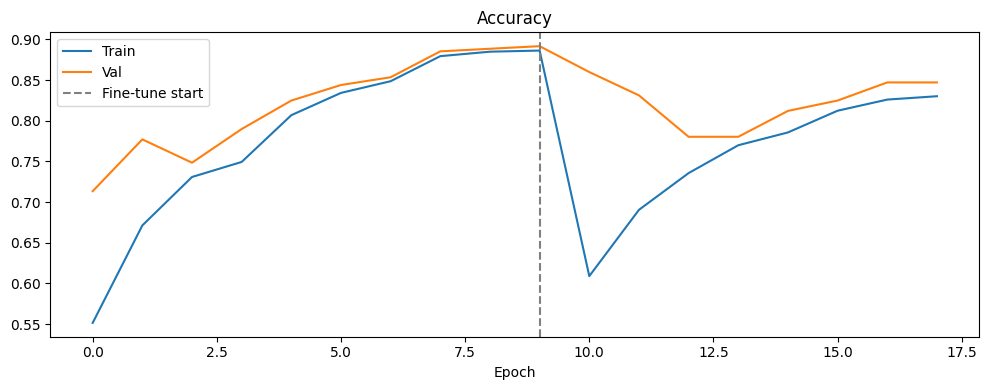

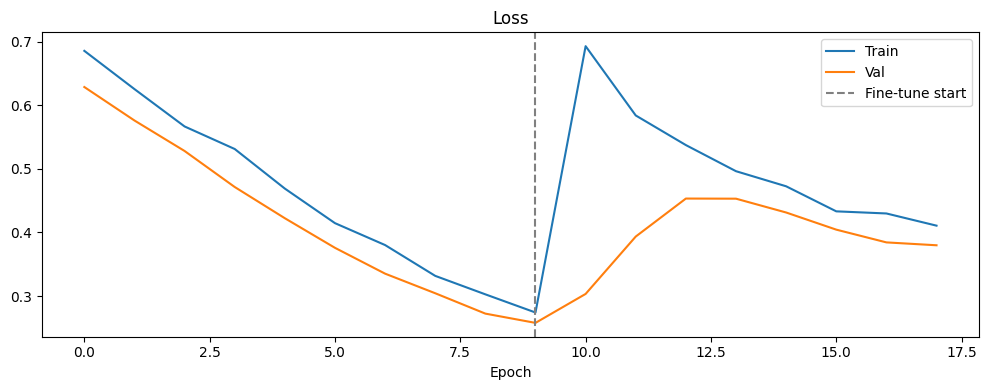

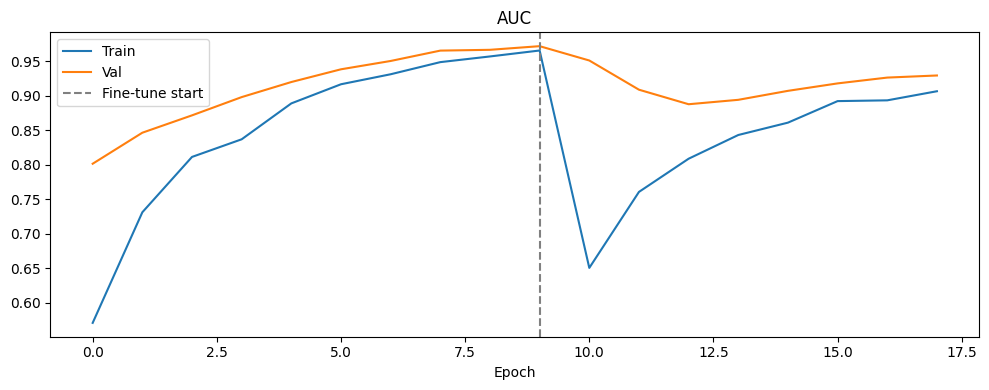

In [9]:
assert 'history1' in dir() and 'history2' in dir(), "Run Cells 7 and 8 first"

def plot_history(h1, h2):
    split = len(h1.epoch)
    for metric, title in [("accuracy", "Accuracy"), ("loss", "Loss"), ("auc", "AUC")]:
        try:
            train_vals = h1.history[metric] + h2.history[metric]
            val_vals = h1.history[f"val_{metric}"] + h2.history[f"val_{metric}"]
        except KeyError:
            print(f"Metric '{metric}' not found, skipping")
            continue

        plt.figure(figsize=(10, 4))
        plt.plot(train_vals, label="Train")
        plt.plot(val_vals, label="Val")
        plt.axvline(split - 1, color="gray", linestyle="--", label="Fine-tune start")
        plt.title(title)
        plt.xlabel("Epoch")
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_history(history1, history2)

# load best model & evaluate

Found 314 images belonging to 2 classes.
Test class indices: {'fake': 0, 'real': 1}
Loaded finetuned model
Last conv layer: top_activation
10/10 [==============================] - 3s 106ms/step - loss: 0.2639 - accuracy: 0.9045 - auc: 0.9715

Test Accuracy: 90.45%
Test AUC: 0.9715
10/10 [==============================] - 3s 100ms/step

Classification Report:
              precision    recall  f1-score   support

        Fake       0.93      0.87      0.90       157
        Real       0.88      0.94      0.91       157

    accuracy                           0.90       314
   macro avg       0.91      0.90      0.90       314
weighted avg       0.91      0.90      0.90       314



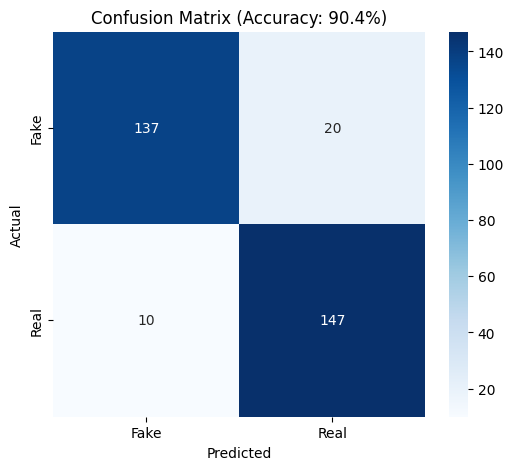

In [10]:
assert os.path.exists(TEST_DIR), "Run Cell 4 first"

# Redefine preprocess and generator locally in case of kernel restart
def preprocess_fn(img):
    return preprocess_input(img)

_eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)
test_gen = _eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode="binary",
    classes=["fake", "real"],
    shuffle=False
)
print(f"Test class indices: {test_gen.class_indices}")
assert test_gen.class_indices == {"fake": 0, "real": 1}, "Class order wrong"

# Load best model safely
if os.path.exists("best_model_finetuned.keras"):
    model = load_model("best_model_finetuned.keras")
    print("Loaded finetuned model")
elif os.path.exists("best_model_phase1.keras"):
    model = load_model("best_model_phase1.keras")
    print("Loaded phase 1 model")
else:
    print("No saved model found, using current in-memory model")

# Re-detect last conv layer after reload
last_conv_layer = None
for layer in reversed(model.layers):
    if len(layer.output.shape) == 4:
        last_conv_layer = layer.name
        break
print(f"Last conv layer: {last_conv_layer}")

# Evaluate
results = model.evaluate(test_gen)
loss = results[0]
acc = results[1]
auc = results[2] if len(results) > 2 else None

print(f"\nTest Accuracy: {acc*100:.2f}%")
if auc:
    print(f"Test AUC: {auc:.4f}")
if acc < 0.60:
    print("Accuracy too low — consider retraining with more data")

# Reset before predict
test_gen.reset()
y_pred_probs = model.predict(test_gen).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            cmap="Blues")
plt.title(f"Confusion Matrix (Accuracy: {acc*100:.1f}%)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# per manipulation type evaluation

In [11]:
assert last_conv_layer is not None, "Run Cell 10 first"

def preprocess_fn(img):
    return preprocess_input(img)

eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

print("Per Manipulation Type Accuracy:\n")

for fake_type in FAKE_DIRS:
    type_dir = f"/kaggle/working/test_by_type/{fake_type}"

    if os.path.exists(type_dir):
        shutil.rmtree(type_dir)
    os.makedirs(f"{type_dir}/fake", exist_ok=True)
    os.makedirs(f"{type_dir}/real", exist_ok=True)

    matched = [f for f in os.listdir(f"{TEST_DIR}/fake")
               if f.lower().startswith(fake_type.lower())]

    if not matched:
        print(f"{fake_type}: no test samples found, skipping")
        continue

    for f in matched:
        shutil.copy(f"{TEST_DIR}/fake/{f}", f"{type_dir}/fake/{f}")

    real_files = os.listdir(f"{TEST_DIR}/real")
    sampled_real = random.sample(real_files, min(len(matched), len(real_files)))
    for f in sampled_real:
        shutil.copy(f"{TEST_DIR}/real/{f}", f"{type_dir}/real/{f}")

    type_gen = eval_datagen.flow_from_directory(
        type_dir,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=32,
        class_mode="binary",
        classes=["fake", "real"],
        shuffle=False,
    )

    if type_gen.samples == 0:
        print(f"{fake_type}: no samples after loading, skipping")
        continue

    type_results = model.evaluate(type_gen, verbose=0)
    type_acc = type_results[1]
    type_auc = type_results[2] if len(type_results) > 2 else None

    line = f"{fake_type}: Accuracy={type_acc*100:.2f}%"
    if type_auc:
        line += f" | AUC={type_auc:.4f}"
    print(line)

Per Manipulation Type Accuracy:

Found 52 images belonging to 2 classes.
Deepfakes: Accuracy=94.23% | AUC=0.9712
Found 52 images belonging to 2 classes.
Face2Face: Accuracy=84.62% | AUC=0.9534
Found 48 images belonging to 2 classes.
FaceSwap: Accuracy=89.58% | AUC=0.9844
Found 46 images belonging to 2 classes.
NeuralTextures: Accuracy=89.13% | AUC=0.9811
Found 58 images belonging to 2 classes.
FaceShifter: Accuracy=91.38% | AUC=0.9762
Found 58 images belonging to 2 classes.
DeepFakeDetection: Accuracy=93.10% | AUC=0.9893


# sample prediction with confidence

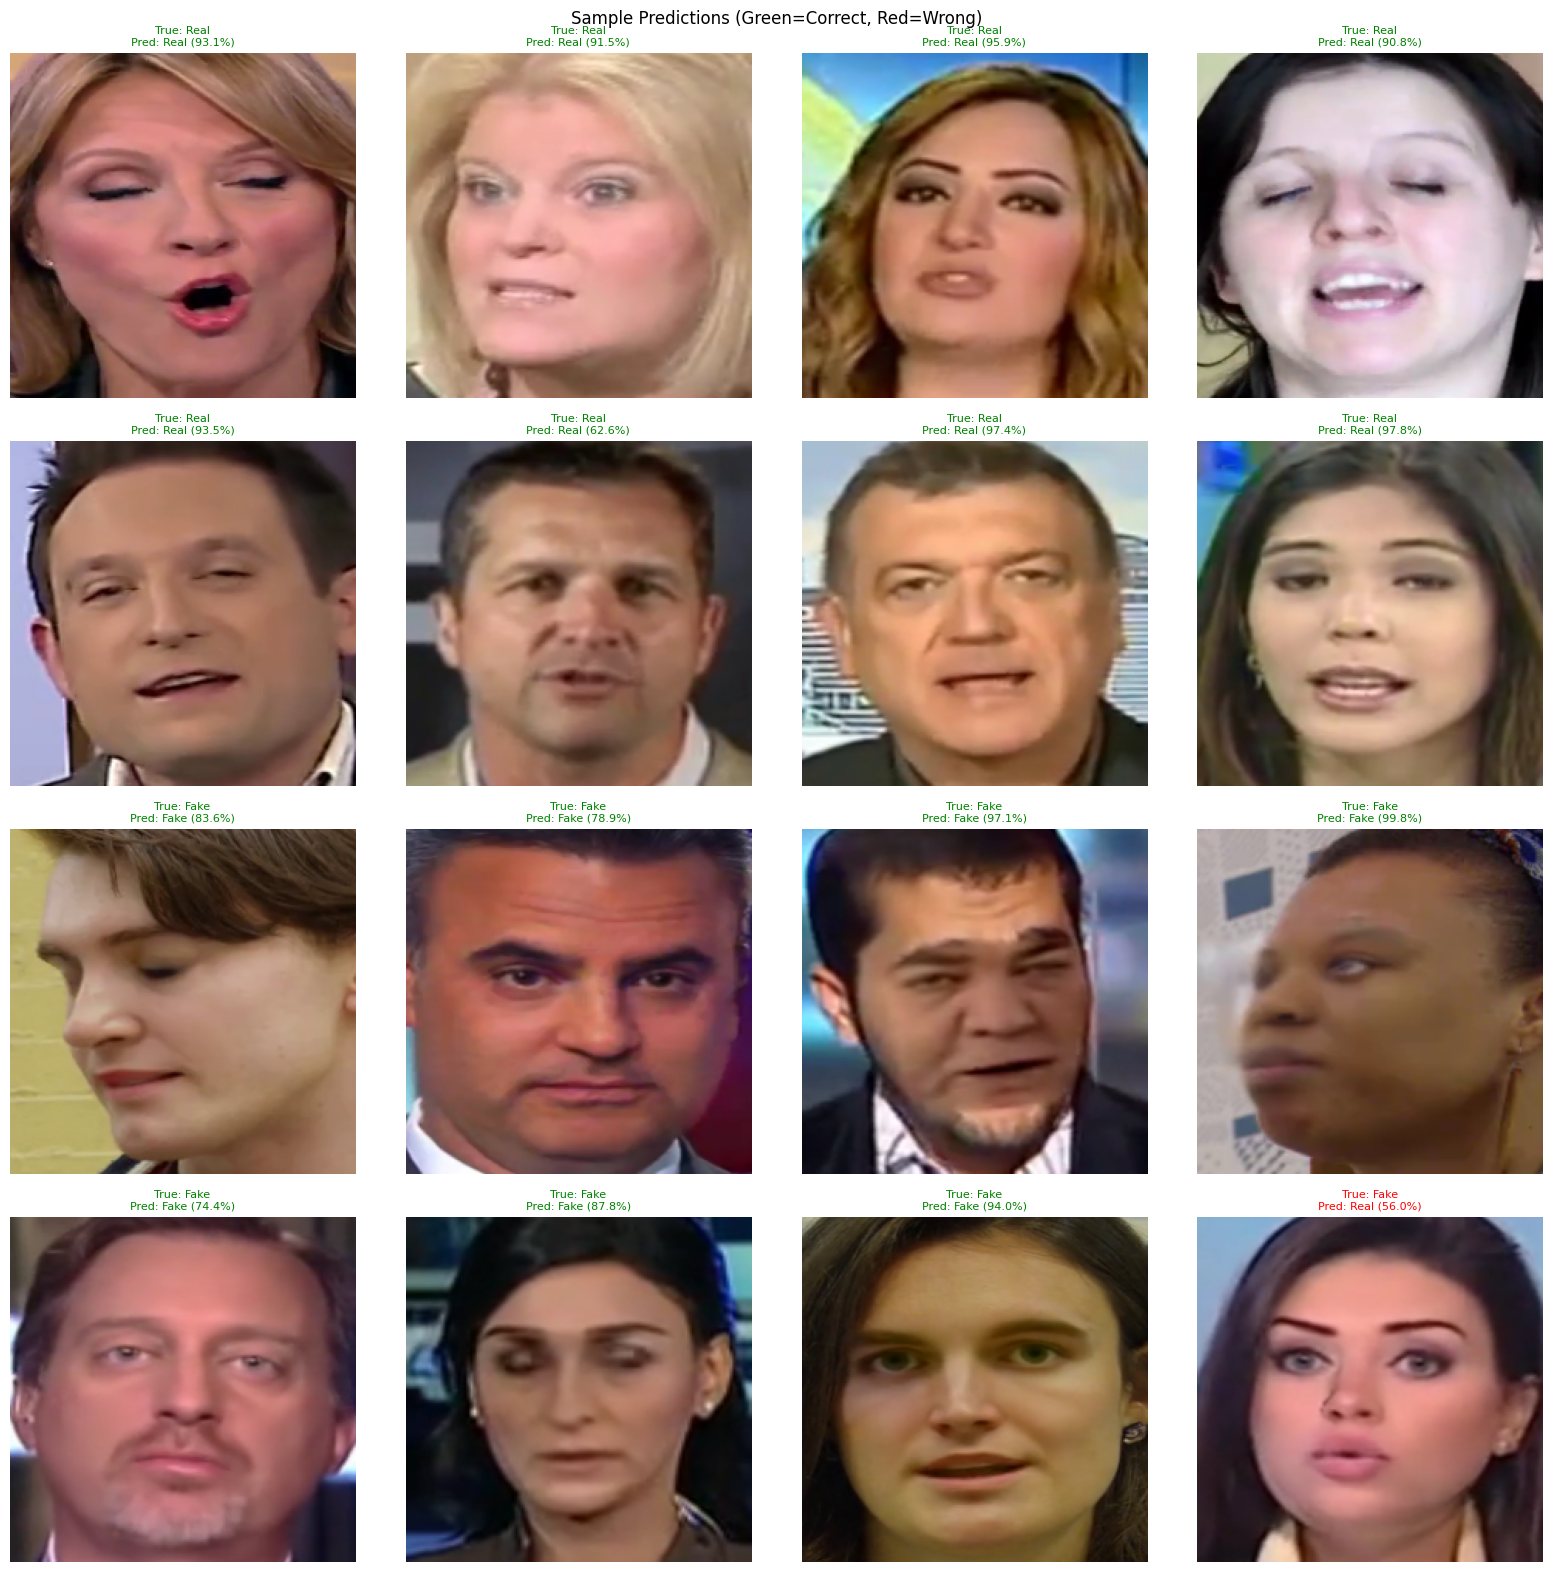

In [15]:
test_images, test_labels = [], []

for cls in ["real", "fake"]:
    folder = f"{TEST_DIR}/{cls}"
    all_files = os.listdir(folder)
    n = min(8, len(all_files))  # safe sample size
    files = random.sample(all_files, n)
    for f in files:
        img = cv2.imread(os.path.join(folder, f))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        test_images.append(img)
        test_labels.append(cls)

def preprocess_fn(img):
    return preprocess_input(img)

imgs_array = preprocess_fn(np.array(test_images).astype("float32"))
preds = model.predict(imgs_array, verbose=0).flatten()

n_total = len(test_images)
cols = 4
rows = (n_total + cols - 1) // cols  # dynamic rows

plt.figure(figsize=(16, rows * 4))
for i, (img, true_label, pred) in enumerate(zip(test_images, test_labels, preds)):
    pred_label = "Real" if pred > 0.5 else "Fake"
    confidence = pred * 100 if pred > 0.5 else (1 - pred) * 100
    correct = pred_label.lower() == true_label

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(
        f"True: {true_label.capitalize()}\nPred: {pred_label} ({confidence:.1f}%)",
        color="green" if correct else "red",
        fontsize=8
    )
    plt.axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()

# grad-CAM

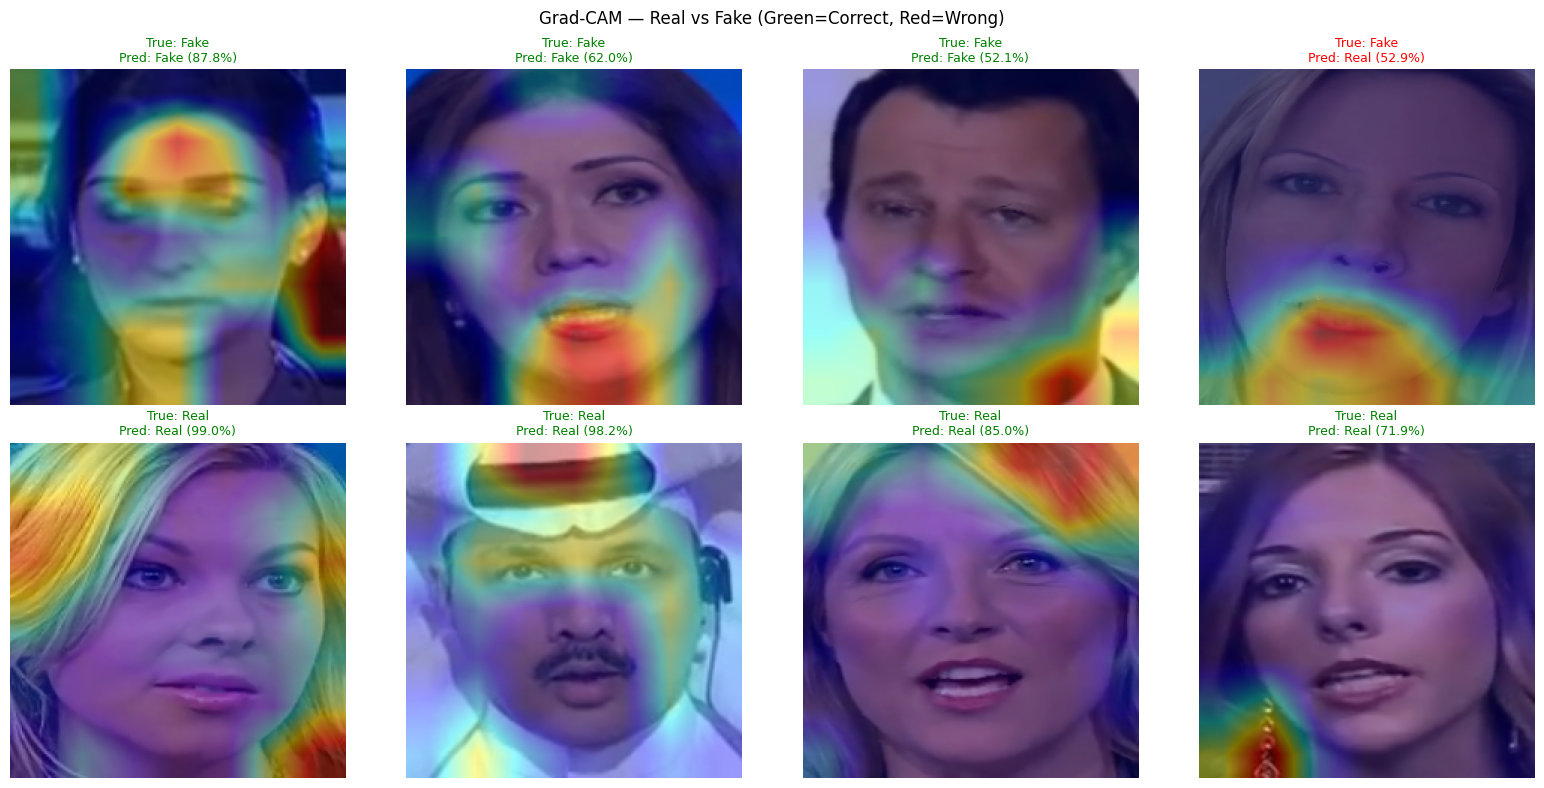

In [16]:
assert last_conv_layer is not None, "Run Cell 10 first"

def preprocess_fn(img):
    return preprocess_input(img)

def get_gradcam_heatmap(model, img_array, conv_layer_name, true_label):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Class-aware: fake=low pred, real=high pred
        if true_label == "Fake":
            loss = 1 - predictions[:, 0]
        else:
            loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img, heatmap):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

n_samples = min(4, len(os.listdir(f"{TEST_DIR}/fake")), len(os.listdir(f"{TEST_DIR}/real")))

sample_paths = (
    [(os.path.join(TEST_DIR, "fake", f), "Fake")
     for f in random.sample(os.listdir(f"{TEST_DIR}/fake"), n_samples)] +
    [(os.path.join(TEST_DIR, "real", f), "Real")
     for f in random.sample(os.listdir(f"{TEST_DIR}/real"), n_samples)]
)

plt.figure(figsize=(16, 8))
for i, (path, true_label) in enumerate(sample_paths):
    img = cv2.imread(path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img_array = preprocess_fn(np.expand_dims(img.astype("float32"), axis=0))
    pred = model.predict(img_array, verbose=0)[0][0]
    pred_label = "Real" if pred > 0.5 else "Fake"
    confidence = pred * 100 if pred > 0.5 else (1 - pred) * 100
    correct = pred_label == true_label

    try:
        heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer, true_label)
        display_img = overlay_gradcam(img, heatmap)
    except Exception as e:
        print(f"Grad-CAM failed for sample {i}: {e}")
        display_img = img

    plt.subplot(2, n_samples, i + 1)
    plt.imshow(display_img)
    plt.title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        color="green" if correct else "red",
        fontsize=9
    )
    plt.axis("off")

plt.suptitle("Grad-CAM — Real vs Fake (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()

# save final model

In [14]:
save_path = "/kaggle/working/deepfake_final_SUBMIT.keras"
model.save(save_path)
print(f"Final model saved to {save_path}")
print("Go to Output tab → Save Version to keep permanently")

Final model saved to /kaggle/working/deepfake_final_SUBMIT.keras
Go to Output tab → Save Version to keep permanently
